In [1]:
"""Hero-Chart 3 (H4): Politisches Rebranding statt Buzzword-Inflation.

Zentrale Aussage: Programme behalten ihren Kern, wechseln aber das Label
beim Regierungswechsel. Hightech-Strategie (Merkel) verschwindet, Zukunfts-
strategie (Ampel) tritt an deren Stelle - bei vergleichbarem Volumen.

Output: figures/h4_rebranding.png + .pdf
"""
import sys
import re
from pathlib import Path
sys.path.insert(0, '..')  # repo root, relativ zum notebooks/-Verzeichnis

In [2]:
import matplotlib.pyplot as plt
from src import FIGURES_DIR
from src.load import load
from src.style import apply_style, COLORS, add_quelle

In [3]:
apply_style()
df = load()  # nutzt Repo-Root-Default aus src.load

In [4]:
def clean_tag(s):
    s = re.sub(r'\{|\}', '', s).strip().lower()
    return re.sub(r'\s+', ' ', s)

In [5]:
def extract_tags(text):
    if not isinstance(text, str):
        return []
    return [clean_tag(t) for t in re.findall(r'\[([^\]]+)\]', text)]

In [6]:
df['tags'] = df['titel_text'].apply(extract_tags)

In [7]:
# Volumen je Jahr fuer beide Begriffe
def vol_pro_jahr(tag):
    has = df['tags'].apply(lambda lst, t=tag: t in lst)
    return {j: df[has & (df['jahr'] == j)]['digi_soll_eng'].sum() / 1e6
            for j in sorted(df['jahr'].unique())}

In [8]:
hightech = vol_pro_jahr('hightech-strategie')
zukunft = vol_pro_jahr('zukunftsstrategie')

In [9]:
jahre = sorted(hightech.keys())
ht_v = [hightech[j] for j in jahre]
zu_v = [zukunft[j] for j in jahre]

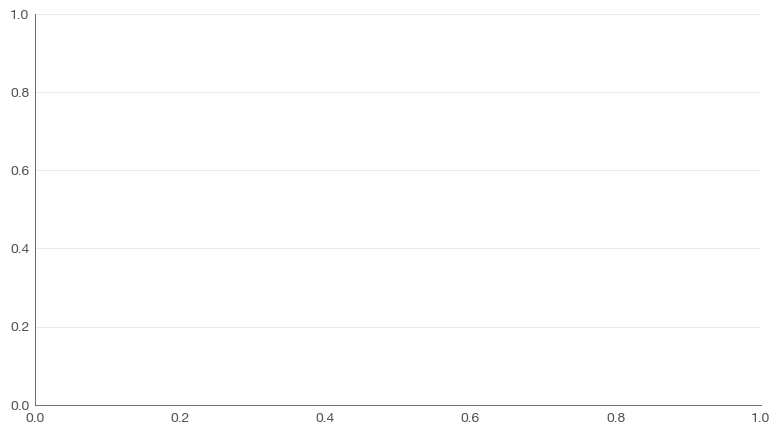

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(11, 6.3))
fig.subplots_adjust(left=0.08, right=0.74, top=0.78, bottom=0.16)

In [11]:
# Hintergrund: Regierungswechsel-Markierung Dez 2021
# Vertikale Linie als visueller Marker
ax.axvline(2021.92, color=COLORS['text_tertiary'], linewidth=0.8,
           linestyle=':', alpha=0.7, zorder=1)
ax.text(2021.92, 2.32, 'Regierungswechsel\nDez 2021', fontsize=8,
        color=COLORS['text_tertiary'], ha='center', style='italic')

Text(2021.92, 2.32, 'Regierungswechsel\nDez 2021')

In [12]:
# Hightech-Linie (faellt)
ax.plot(jahre, ht_v, color=COLORS['rueckgang'], linewidth=2.8,
        marker='o', markersize=9, zorder=3)
# Zukunfts-Linie (steigt)
ax.plot(jahre, zu_v, color=COLORS['aufstieg'], linewidth=2.8,
        marker='s', markersize=9, zorder=3)

In [13]:
# Endpunkt-Beschriftungen (nur fuer Punkte mit Volumen > 50 Mio)
for j_idx, j in enumerate(jahre):
    if ht_v[j_idx] > 0.05:
        ax.text(j, ht_v[j_idx] + 0.08, f'{ht_v[j_idx]:.2f} Mrd €',
                ha='center', fontsize=10, color=COLORS['rueckgang'], weight='medium')
    if zu_v[j_idx] > 0.05:
        ax.text(j, zu_v[j_idx] + 0.08, f'{zu_v[j_idx]:.2f} Mrd €',
                ha='center', fontsize=10, color=COLORS['aufstieg'], weight='medium')

In [14]:
# Direkte Linien-Labels - links an Start-Punkt, rechts an End-Punkt
ax.text(2018.7, ht_v[0], 'Hightech-\nStrategie',
        ha='right', va='center', fontsize=11,
        color=COLORS['rueckgang'], weight='medium')
ax.text(2024.3, zu_v[-1], 'Zukunfts-\nstrategie',
        ha='left', va='center', fontsize=11,
        color=COLORS['aufstieg'], weight='medium')

Text(2024.3, 1.8887739315865424, 'Zukunfts-\nstrategie')

In [15]:
# Achsen
ax.set_xticks(jahre)
ax.set_xticklabels([str(j) for j in jahre])
ax.set_xlim(2017.7, 2025.0)
ax.set_ylim(-0.05, 2.5)
ax.set_ylabel('Volumen je Schlagwort (Mrd €, enge Abgrenzung)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))

In [16]:
# Titel
fig.text(0.04, 0.93,
         'Politisches Rebranding statt Buzzword-Inflation',
         fontsize=15, weight='medium', color=COLORS['text'])
fig.text(0.04, 0.89,
         'Ein Förder-Etikett verschwindet vollständig, ein anderes nimmt seinen Platz ein – ohne Bruch im Volumen.',
         fontsize=10, color=COLORS['text_secondary'])

Text(0.04, 0.89, 'Ein Förder-Etikett verschwindet vollständig, ein anderes nimmt seinen Platz ein – ohne Bruch im Volumen.')

In [17]:
# Rechte Spalte: Volumen-Uebergabe
fig.text(0.77, 0.75, 'Volumen-Übergabe',
         fontsize=11, color=COLORS['text'], weight='medium')

Text(0.77, 0.75, 'Volumen-Übergabe')

In [18]:
fig.text(0.77, 0.68, '2019 (CDU-geführt)',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.635, 'Hightech-Strategie',
         fontsize=10, color=COLORS['rueckgang'])
fig.text(0.77, 0.585, f'{ht_v[0]:.2f} Mrd €',
         fontsize=18, color=COLORS['rueckgang'], weight='bold')

Text(0.77, 0.585, '1.32 Mrd €')

In [19]:
fig.text(0.77, 0.475, '2024 (Ampel)',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.430, 'Zukunftsstrategie',
         fontsize=10, color=COLORS['aufstieg'])
fig.text(0.77, 0.380, f'{zu_v[-1]:.2f} Mrd €',
         fontsize=18, color=COLORS['aufstieg'], weight='bold')

Text(0.77, 0.38, '1.89 Mrd €')

In [20]:
fig.text(0.77, 0.28, f'Volumen ×{zu_v[-1]/ht_v[0]:.2f}',
         fontsize=10, color=COLORS['text'], weight='medium')
fig.text(0.77, 0.245, 'bei vollständigem',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.215, 'Label-Tausch',
         fontsize=9, color=COLORS['text_secondary'])

Text(0.77, 0.215, 'Label-Tausch')

In [21]:
fig.text(0.04, 0.02,
         'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. '
         'ZEW-Schlagwörter in eckigen Klammern aus titel_text extrahiert.',
         fontsize=8, color=COLORS['text_tertiary'], style='italic')

Text(0.04, 0.02, 'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. ZEW-Schlagwörter in eckigen Klammern aus titel_text extrahiert.')

In [22]:
# Speichern
out_dir = FIGURES_DIR
fig.savefig(out_dir / 'h4_rebranding.png', dpi=200)
fig.savefig(out_dir / 'h4_rebranding.pdf')
print(f"Gespeichert: {out_dir/'h4_rebranding.png'}")
print(f"Gespeichert: {out_dir/'h4_rebranding.pdf'}")

Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h4_rebranding.png
Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h4_rebranding.pdf
